In [ ]:
# --- repo path setup (added during reorg) ---
import sys, os
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), '..', 'src')))


Patches shape: (3, 6)
Grid: 41 eps_a x 41 eps_c = 1681 points
Factor: 6
Solver: numba, device: cpu
Building geometry cache (one-time cost) ...
  130 canonical groups cached.
  Solver: numba, device: cpu (numba)


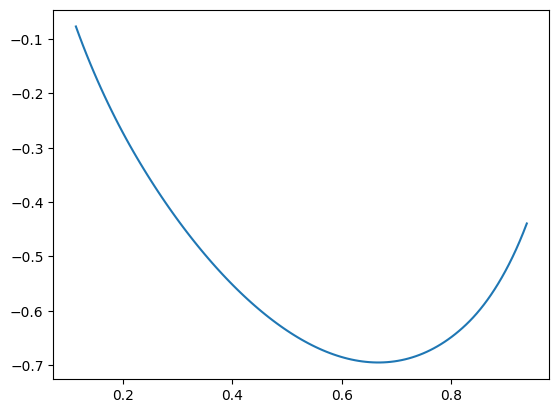

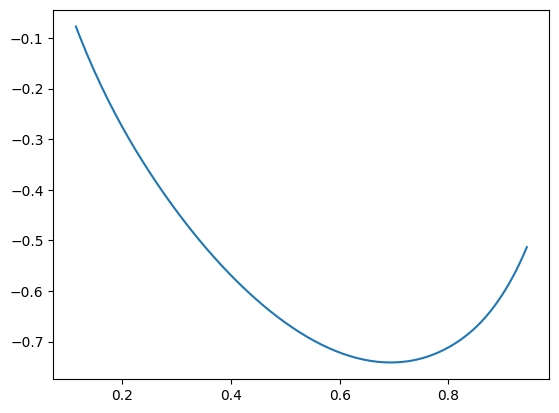

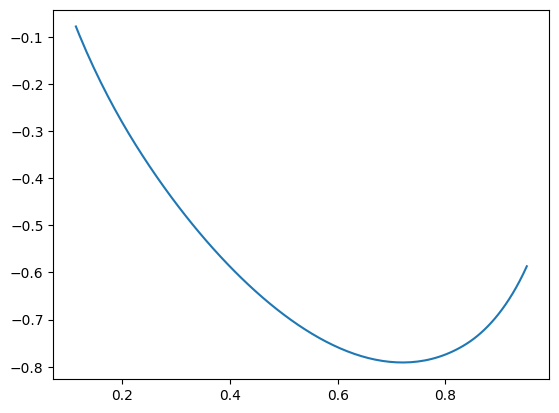

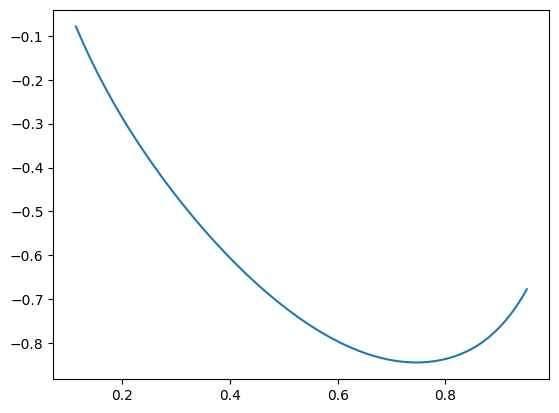

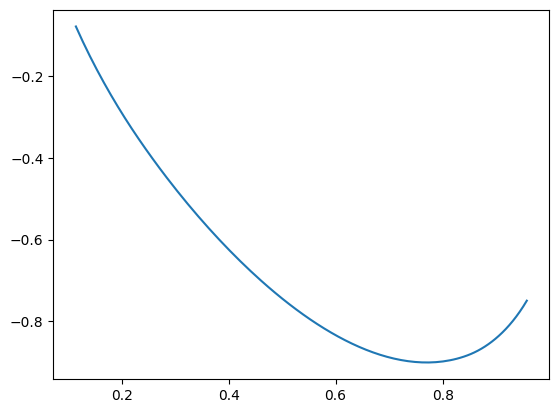

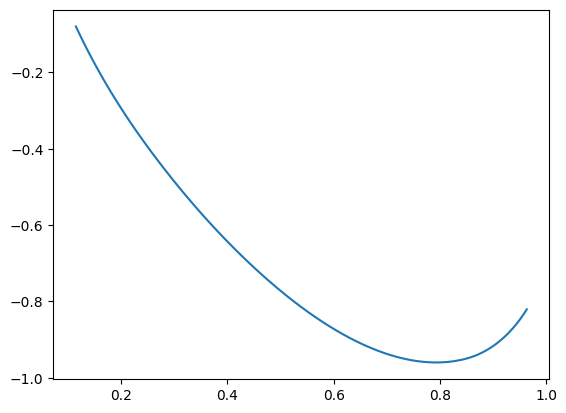

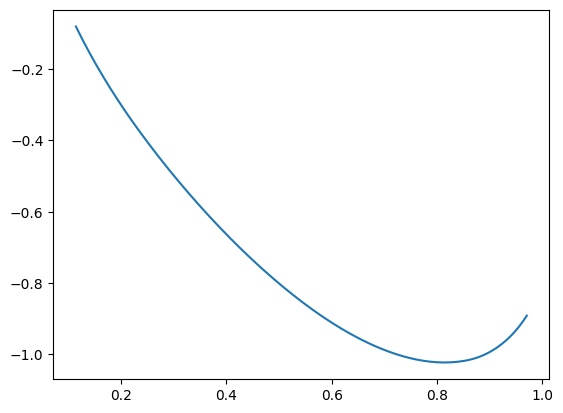

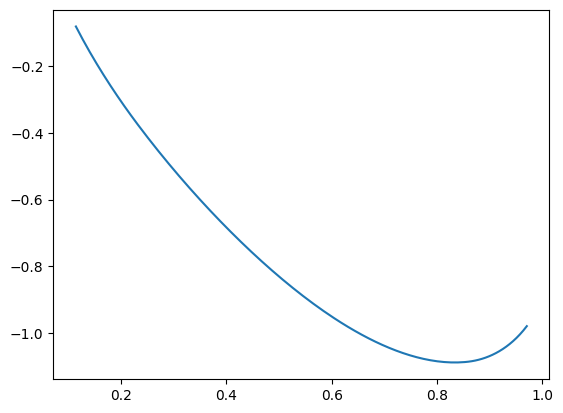

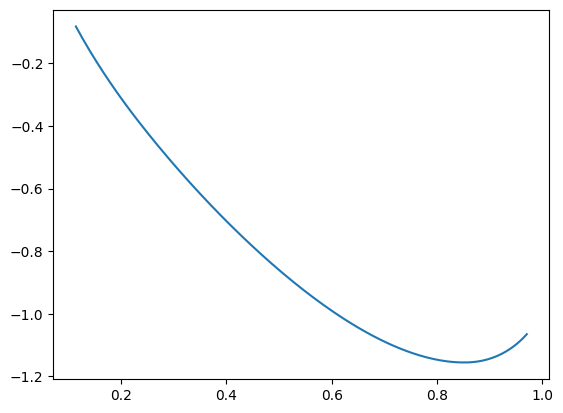

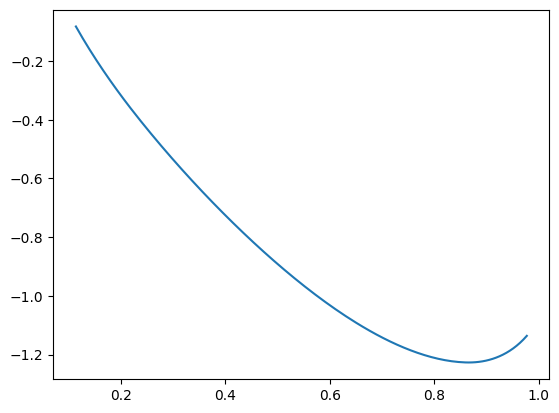

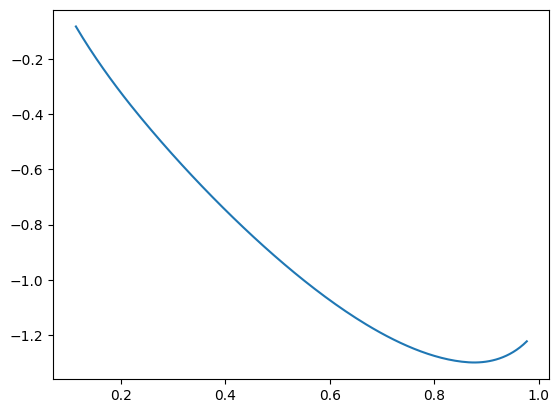

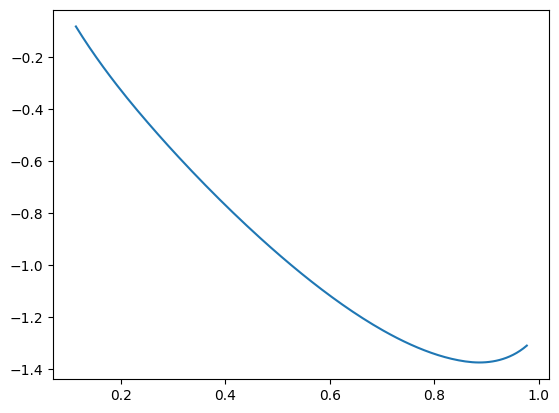

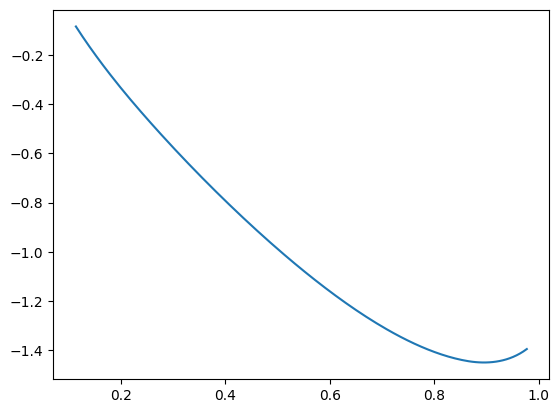

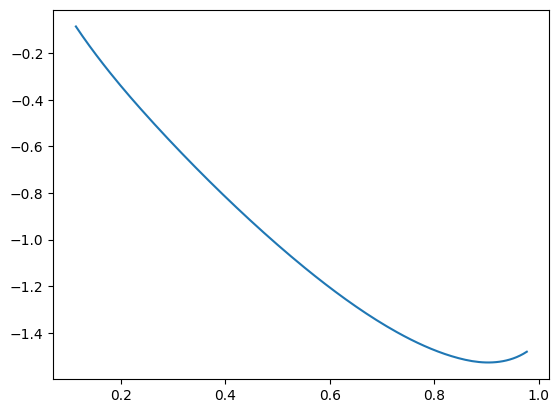

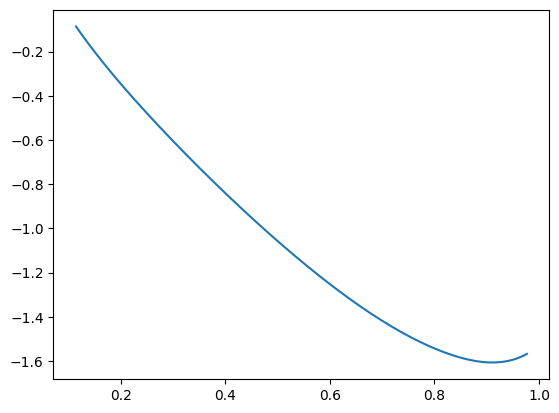

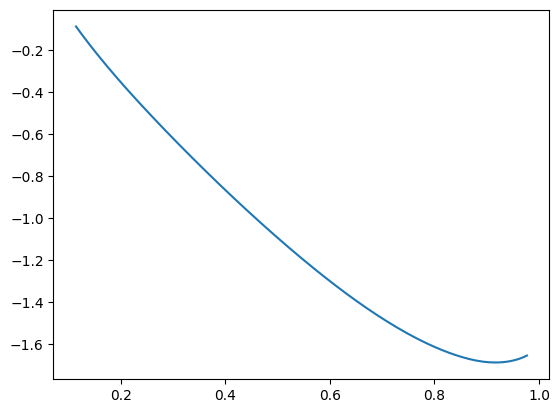

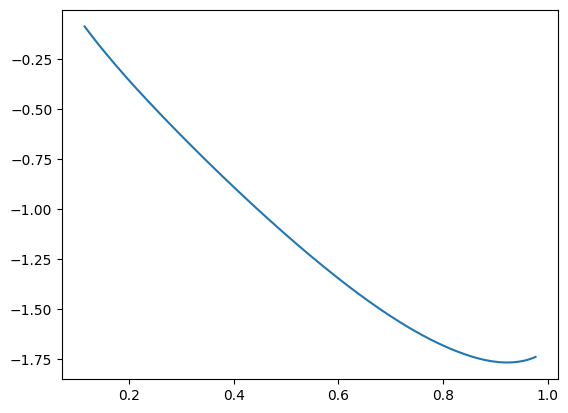

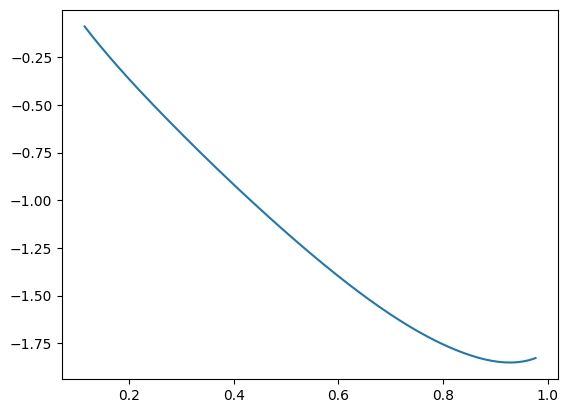

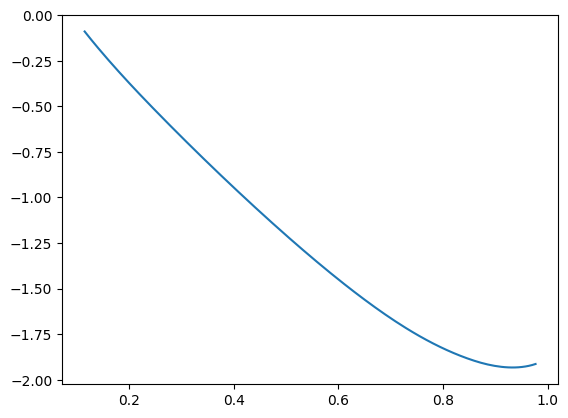

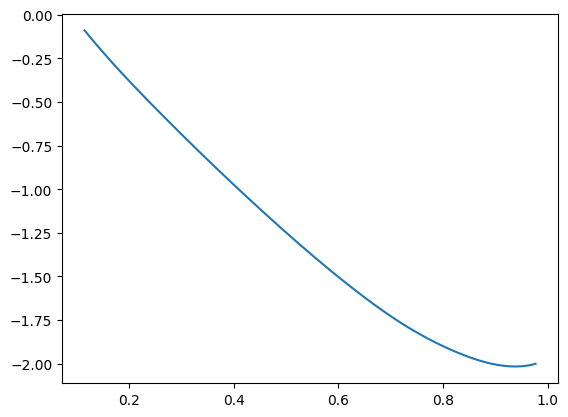

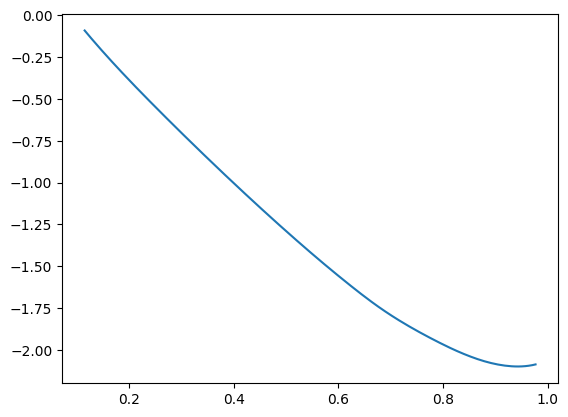

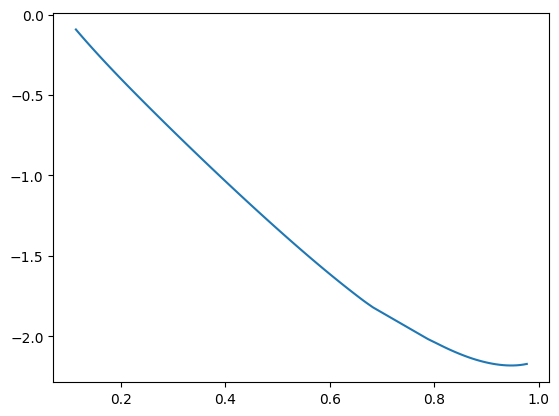


KeyboardInterrupt



In [1]:
import numpy as np
import torch
import matplotlib.pyplot as plt
import torch.nn.functional as F
from scipy.spatial import ConvexHull

from plaquette_by_species_hexagon import (build_hexagon7_by_species, residual_free_energy_simple,
    build_hexagon7_geometry_cache, hexagon7_from_cache, prune_hexagon7_cache,
    build_S_matrix, solve_free_energy_curve_reduced)


# --------------------------------------------------------------------------
# Helper functions
# --------------------------------------------------------------------------

def loess_derivs(x, y, *, bandwidth=0.15, order=2):
    x = torch.as_tensor(x, dtype=torch.float64)
    y = torch.as_tensor(y, dtype=torch.float64)
    n = x.shape[0]
    f0 = torch.zeros(n, dtype=torch.float64)
    f1 = torch.zeros(n, dtype=torch.float64)
    f2 = torch.zeros(n, dtype=torch.float64)
    h = bandwidth * (x.max() - x.min())
    for i in range(n):
        d = (x - x[i]).abs()
        w = torch.clamp(1 - (d / h) ** 3, min=0) ** 3
        dx = x - x[i]
        cols = [torch.ones_like(dx)]
        if order >= 1:
            cols.append(dx)
        if order >= 2:
            cols.append(dx ** 2)
        X = torch.stack(cols, dim=1)
        XTW = (X.T * w)
        
        beta = torch.linalg.solve(XTW @ X, XTW @ y)
        f0[i] = beta[0]
        f1[i] = beta[1] if order >= 1 else torch.nan
        f2[i] = (2 * beta[2]) if order >= 2 else torch.nan
    return f0, f1, f2


def _stack_constraints(A, phi, G=None):
    A = np.atleast_2d(A).astype(np.float64)
    rows = [A]
    rhs = [np.array([phi], dtype=np.float64)]
    if G is not None:
        rows.append(G.astype(np.float64))
        rhs.append(np.zeros(G.shape[0], dtype=np.float64))
    return np.vstack(rows), np.concatenate(rhs)


def constrained_softmax(z, C, d, tol=1e-10, max_newton=50, ridge=1e-12):
    m, _ = C.shape
    eta = torch.zeros(m, dtype=z.dtype, device=z.device, requires_grad=True)
    for _ in range(max_newton):
        logits = z + C.t().matmul(eta)
        rho = F.softmax(logits, dim=0)
        g = C.matmul(rho) - d
        if torch.linalg.norm(g) <= tol:
            break
        W = C * rho.unsqueeze(0)
        J = W.matmul(C.t()) - torch.outer(C.matmul(rho), C.matmul(rho))
        J = J + ridge * torch.eye(m, dtype=z.dtype, device=z.device)
        delta = torch.linalg.solve(J, -g)
        delta = torch.clamp(delta, -50.0, 50.0)
        eta = eta + delta
    logits = z + C.t().matmul(eta)
    rho = F.softmax(logits, dim=0)
    res = torch.linalg.norm(C.matmul(rho) - d)
    return rho, eta, float(res.item())


def monomer_free_energy_from_clusters(
    phi,
    A,
    f_tilde_torch,
    G=None,
    steps=4000,
    lr=0.5,
    tol_res=1e-5,
    device="cpu",
    dtype=torch.float64,
    z0=None,
):
    C_np, d_np = _stack_constraints(A, phi, G)
    C = torch.tensor(C_np, dtype=dtype, device=device)
    d = torch.tensor(d_np, dtype=dtype, device=device)
    _, P = C.shape

    z = (torch.zeros(P, dtype=dtype, device=device) if z0 is None else z0.clone().detach()).requires_grad_(True)
    opt = torch.optim.Adagrad([z], lr=lr)
    best = {"f": float("inf"), "rho": None, "z": None, "res": float("inf")}
    prev_f = None

    for _ in range(steps):
        rho, _, _ = constrained_softmax(z, C, d, tol=tol_res)
        f = f_tilde_torch(rho)
        opt.zero_grad()
        f.backward()
        with torch.no_grad():
            grad_norm = float(z.grad.norm().item()) if z.grad is not None else float("nan")
        opt.step()

        with torch.no_grad():
            rho2, _, res2 = constrained_softmax(z, C, d, tol=tol_res)
            f2 = float(f_tilde_torch(rho2).item())
            if f2 < best["f"] and res2 < best["res"]:
                best["f"] = f2
                best["rho"] = rho2.clone()
                best["res"] = res2
                best["z"] = z.clone()

        if prev_f is not None and abs(f2 - prev_f) <= tol_res:
            break
        prev_f = f2
        if grad_norm <= tol_res or np.isnan(grad_norm):
            break

    rho_star = best["rho"] if best["rho"] is not None else constrained_softmax(z.detach(), C, d, tol=tol_res)[0].detach()
    z_star = best["z"] if best["z"] is not None else z.detach()
    f_phi = float(f_tilde_torch(rho_star).item())
    residual = float(torch.linalg.norm(C @ rho_star - d).item())
    return {"f_phi": f_phi, "rho": rho_star.cpu().numpy(), "residual": residual, "z": z_star}


def zero_crossings_linear(phis, y, tol=1e-6):
    z = []
    for i in range(len(phis) - 1):
        y1, y2 = y[i], y[i + 1]
        if abs(y1) < tol:
            z.append(float(phis[i]))
            continue
        if y1 * y2 < 0:
            t = -y1 / (y2 - y1)
            z.append(float(phis[i] + t * (phis[i + 1] - phis[i])))
    if abs(y[-1]) < tol:
        z.append(float(phis[-1]))
    return z


def free_energy_curve_with_derivs_and_spinodal(
    phi_grid,
    A_row,
    f_tilde_torch,
    *,
    G=None,
    device="cpu",
    dtype=torch.float64,
    steps=400,
    lr=0.5,
    tol_res=1e-4,
    z_vectors_init=None,
):
    phi_grid = np.asarray(phi_grid, float)
    n_phi = len(phi_grid)
    phi_lo, phi_hi = float(A_row.min()), float(A_row.max())
    fvals, rhos, residuals = [], [], []
    z_vectors = [None] * n_phi
    z0 = None
    for idx, phi in enumerate(phi_grid):
        if phi < phi_lo - 1e-6 or phi > phi_hi + 1e-6:
            fvals.append(float('nan'))
            rhos.append(None)
            residuals.append(float('inf'))
            continue
        z_init = z0
        if z_init is None and z_vectors_init is not None and z_vectors_init[idx] is not None:
            z_init = z_vectors_init[idx]
        out = monomer_free_energy_from_clusters(
            phi=phi,
            A=A_row,
            f_tilde_torch=f_tilde_torch,
            G=G,
            steps=steps,
            lr=lr,
            tol_res=tol_res,
            device=device,
            dtype=dtype,
            z0=z_init,
        )
        res = out["residual"]
        residuals.append(res)
        if res > tol_res * 10:
            fvals.append(float('nan'))
            rhos.append(out["rho"])
        else:
            fvals.append(out["f_phi"])
            rhos.append(out["rho"])
        z0 = out["z"]
        z_vectors[idx] = out["z"]

    fvals = np.asarray(fvals, float)
    valid = ~np.isnan(fvals)
    phi_valid = phi_grid[valid]
    f_valid = fvals[valid]
    if len(phi_valid) < 5:
        return {"phi": phi_grid, "f": fvals, "phi_inner": phi_valid, "f_smooth": f_valid,
                "fp": np.zeros_like(f_valid), "fpp": np.zeros_like(f_valid),
                "spinodal_phis": [], "rhos": rhos, "z_vectors": z_vectors}
    margin = min(2, len(phi_valid) // 4)
    phi_inner = phi_valid[margin:-margin] if margin > 0 else phi_valid
    f_inner = f_valid[margin:-margin] if margin > 0 else f_valid
    f_smooth, fp, fpp = loess_derivs(phi_inner, f_inner)
    spinodal_phis = zero_crossings_linear(phi_inner, -fpp.detach().cpu().numpy(), tol=1e-6)
    return {
        "phi": phi_grid,
        "f": fvals,
        "phi_inner": phi_inner,
        "f_smooth": f_smooth,
        "fp": fp,
        "fpp": fpp,
        "spinodal_phis": spinodal_phis,
        "rhos": rhos,
        "z_vectors": z_vectors,
    }


# --------------------------------------------------------------------------
# Binodal helpers
# --------------------------------------------------------------------------

def extract_binodals_from_convex_envelope(phi, f, *, hull_tol=0.0, coexist_tol=1e-5, min_gap_points=6):
    del hull_tol
    phi = np.asarray(phi, float)
    f = np.asarray(f, float)
    pts = np.column_stack([phi, f])
    try:
        hull = ConvexHull(pts)
    except Exception:
        return {"phi": phi, "f": f, "hull_idx": [], "segments": []}

    hull_idx = np.sort(hull.vertices)
    out = []
    for k in range(len(hull_idx) - 1):
        i, j = hull_idx[k], hull_idx[k + 1]
        if j - i < min_gap_points:
            continue
        phi1, phi2 = phi[i], phi[j]
        f1, f2 = f[i], f[j]
        mu_line = (f2 - f1) / (phi2 - phi1 + 1e-30)
        line = f1 + mu_line * (phi - phi1)
        diff = f - line
        mask = (phi >= phi1) & (phi <= phi2)
        if not np.any(mask):
            continue
        barrier = float(np.max(diff[mask]))
        below_min = float(np.min(diff[mask]))
        if barrier < coexist_tol:
            continue
        out.append(
            {
                "phi1": float(phi1),
                "phi2": float(phi2),
                "mu": float(mu_line),
                "barrier": barrier,
                "below_min": below_min,
                "n_points": int(j - i),
            }
        )
    return {"phi": phi, "f": f, "hull_idx": hull_idx.tolist(), "segments": out}


def best_binodal_segment(result, *, prefer="largest_barrier"):
    segs = result.get("segments", [])
    if not segs:
        return None
    if prefer == "widest":
        key = lambda d: (d["phi2"] - d["phi1"])
    elif prefer == "most_points":
        key = lambda d: d["n_points"]
    else:
        key = lambda d: ((d["phi2"] - d["phi1"]), d["barrier"])
    return max(segs, key=key)


def common_tangent_line(phi, f, binodal):
    phi = np.asarray(phi, float)
    f = np.asarray(f, float)
    phi1 = float(binodal["phi1"])
    mu = float(binodal["mu"])
    f1 = float(np.interp(phi1, phi, f))
    c = f1 - mu * phi1
    line = mu * phi + c
    return line, c


def excess_above_tangent(phi, f, binodal):
    line, _ = common_tangent_line(phi, f, binodal)
    g = f - line
    return g, line


def plot_barrier(phi, f, binodal, *, ax=None):
    phi = np.asarray(phi, float)
    f = np.asarray(f, float)
    phi1 = float(binodal["phi1"])
    phi2 = float(binodal["phi2"])
    g, _ = excess_above_tangent(phi, f, binodal)
    if ax is None:
        _, ax = plt.subplots()
    ax.plot(phi, g, label="g(φ)=f(φ)-tangent")
    ax.axhline(0.0)
    ax.axvline(phi1)
    ax.axvline(phi2)
    ax.set_xlabel("φ")
    ax.set_ylabel("g(φ)")
    ax.legend()
    return ax


# --------------------------------------------------------------------------
# Hexagon7 spinodal / binodal scan
# --------------------------------------------------------------------------

def find_spinodal_hexagon7_simple(
    patches,
    eps_as,
    eps_cs,
    factor,
    z=6,
    lr=0.05,
    tol=1e-4,
    rot60_species=None,
    canonicalize_by_boundary_edges=True,
    plot_each=True,
    phis=None,
    chunk_size=200_000,
    device="cpu",
    prune_threshold=0,
    solver="torch",
):
    """
    Hexagon7 spinodal / binodal scan.

    solver : "torch" (GPU-friendly, uses autograd) or "numba" (CPU, reduced 16-dim Newton)
    device : "cpu" or "cuda" (only used when solver="torch")
    """
    phis = np.linspace(0.01, 0.99, 151) if phis is None else np.asarray(phis, dtype=float)
    eps_as = np.asarray(eps_as, dtype=float)
    eps_cs = np.asarray(eps_cs, dtype=float)
    n_patch_types = int(np.max(patches)) + 1
    dtype = torch.float64

    if solver == "torch" and device != "cpu" and not torch.cuda.is_available():
        print(f"Warning: device={device!r} requested but CUDA not available, falling back to cpu")
        device = "cpu"

    print("Building geometry cache (one-time cost) ...")
    cache = build_hexagon7_geometry_cache(
        patches,
        rot60_species=rot60_species,
        canonicalize_by_boundary_edges=canonicalize_by_boundary_edges,
        chunk_size=chunk_size,
    )
    print(f"  {cache['n_groups']} canonical groups cached.")

    if prune_threshold > 0:
        corners = []
        for ea in [float(eps_as.min()), float(eps_as.max())]:
            for ec in [float(eps_cs.min()), float(eps_cs.max())]:
                Jc = np.zeros((n_patch_types, n_patch_types), dtype=np.float64)
                Jc[1, 1] = -ea
                Jc[:-1, :-1] -= ec
                corners.append(Jc)
        cache = prune_hexagon7_cache(cache, corners, threshold=prune_threshold)
        print(f"  {cache['n_groups']} groups after pruning (threshold={prune_threshold:.0e}).")

    # Pre-build S matrix for numba path
    P = cache["n_groups"]
    Fd = len(cache["unique_face_ids"])
    S_mat = build_S_matrix(cache["patch_to_species"], cache["patch_to_small"],
                           cache["m_patch"], P, Fd)

    # Persistent tensors for torch path (moved to device)
    if solver == "torch":
        patch_to_species_t = torch.from_numpy(cache["patch_to_species"]).long().to(device)
        patch_to_small_t = torch.from_numpy(cache["patch_to_small"]).long().to(device)
        m_patch_t = torch.from_numpy(cache["m_patch"]).to(dtype).to(device)

    print(f"  Solver: {solver}, device: {device if solver == 'torch' else 'cpu (numba)'}")

    points = []
    binodals_out = []
    prev_z_vectors = None
    prev_mu_W = None

    total = len(eps_cs) * len(eps_as)
    done = 0

    for eps_c in eps_cs:
        for eps_a in eps_as:
            done += 1
            J = np.zeros((n_patch_types, n_patch_types), dtype=np.float64)
            J[1, 1] = -eps_a
            J[:-1, :-1] -= eps_c

            (eps_s, intra_bonds, hex_to_species, _mp, _pts, _pss,
             hex_configs, mult) = hexagon7_from_cache(cache, J)

            A_row = np.sum(hex_to_species[:, :-1], axis=1).astype(np.float64) / 7.0

            # ---- numba path ----
            
            if solver == "numba":
                log_mult_np = np.log(mult.astype(np.float64) + 1e-300)
                delta_np = (np.exp(-eps_s) - 1.0) / factor
                mu0, W0 = (prev_mu_W if prev_mu_W is not None
                           else (0.0, None))
                curve_r = solve_free_energy_curve_reduced(
                    phis, A_row, intra_bonds.astype(np.float64),
                    log_mult_np, S_mat, delta_np,
                    mu_init=mu0, W_init=W0,
                    max_newton=60, tol=1e-10,
                )
                prev_mu_W = curve_r["mu_W"]
                phi_arr = curve_r["phi"]
                f_arr = curve_r["f"]

            # ---- torch path (GPU-friendly) ----
            else:
                eps_small_t = torch.tensor(-eps_s, dtype=dtype, device=device)
                mult_t = torch.from_numpy(mult).to(dtype).to(device)
                e_linear_t = torch.tensor(intra_bonds, dtype=dtype, device=device)
                delta_small = torch.expm1(eps_small_t).div(factor)
                _X0 = None

                def f_tilde_torch(rho_t):
                    nonlocal _X0
                    f_val, X = residual_free_energy_simple(
                        rho_t, 1, z,
                        patch_to_species_t, patch_to_small_t,
                        eps_small_t, m_patch_t, e_linear_t,
                        delta_small, mult_t,
                        X0=_X0, return_X=True,
                    )
                    _X0 = X
                    return f_val
                
                curve = free_energy_curve_with_derivs_and_spinodal(
                    phis, A_row, f_tilde_torch,
                    device=device, dtype=dtype,
                    steps=1000, lr=lr, tol_res=tol,
                    z_vectors_init=prev_z_vectors,
                )
                prev_z_vectors = curve.get("z_vectors")
                phi_arr = np.asarray(curve["phi"], float)
                f_arr = np.asarray(curve["f"], float)

            # --- common post-processing ---
            try:
                valid = ~np.isnan(f_arr)
                phi_v = phi_arr[valid]
                f_v = f_arr[valid]
                if len(phi_v) < 5:
                    if done % 50 == 0 or done == total:
                        print(f"  [{done}/{total}] eps_a={eps_a:.3f} eps_c={eps_c:.3f}  (skip: <5 valid)")
                    continue
                margin = min(2, len(phi_v) // 4)
                phi_inner = phi_v[margin:-margin] if margin > 0 else phi_v
                f_inner = f_v[margin:-margin] if margin > 0 else f_v
                f_smooth_t, _, _ = loess_derivs(phi_inner, f_inner)
                f_smooth = f_smooth_t.detach().cpu().numpy()

                fpp_t = loess_derivs(phi_inner, f_inner)[2]
                sp = zero_crossings_linear(phi_inner, -fpp_t.detach().cpu().numpy(), tol=1e-6)
                res = extract_binodals_from_convex_envelope(
                    phi_inner, f_smooth,
                    hull_tol=0.0, coexist_tol=1e-3, min_gap_points=6,
                )
                binodal = best_binodal_segment(res, prefer="largest_barrier")
                plt.plot(phi_inner, f_smooth)
                plt.show()
                if done % 50 == 0 or done == total:
                    print(f"  [{done}/{total}] eps_a={eps_a:.3f} eps_c={eps_c:.3f}")
                if binodal is not None and len(sp) > 1 and binodal["barrier"] > 1e-4:
                    points.append((float(eps_a), float(eps_c)))
                    binodals_out.append(binodal)
                    if plot_each:
                        plot_barrier(phi_inner, f_smooth, binodal)
                        plt.show()
            except torch.linalg.LinAlgError:
                continue
    return binodals_out, points


# Backward-style alias
find_spinodal_hexagon7 = find_spinodal_hexagon7_simple
# --------------------------------------------------------------------------
# Setup: patches and parameter grid
# --------------------------------------------------------------------------

patches = np.array([
    [1, 0, 1, 0, 1,0],
    [0, 1, 0, 1, 0,1],
    [2, 2, 2, 2, 2,2],  # vacancy
])

# Rotation map: species 0->1->2->3->0, vacancy stays
rot60_species = np.array([1,0,2])

# Parameter grid
z = 6
eps_as = np.linspace(0, 4, 41)
eps_cs = np.linspace(0, 1.1, 41)
factor = 6

print(f"Patches shape: {patches.shape}")
print(f"Grid: {len(eps_as)} eps_a x {len(eps_cs)} eps_c = {len(eps_as)*len(eps_cs)} points")
print(f"Factor: {factor}")
import json
import numpy as np

def save_spinodal_hexagon7_results(
    binodals,
    points,
    eps_as,
    eps_cs,
    factor,
    patches,
    rot60_species,
    z,
    canonicalize_by_boundary_edges=True,
    chunk_size=200_000,
    base_filename="../data/spinodal_hexagon7_results",
):
    """
    Save results from find_spinodal_hexagon7_simple.

    Parameters
    ----------
    binodals : list[dict]
        Each dict is expected to contain keys like:
        'phi1', 'phi2', 'mu', 'barrier', 'below_min', 'n_points'
    points : list[tuple[float, float]]
        (eps_a, eps_c) points where a binodal was found
    eps_as, eps_cs : array-like
        Parameter grids used in the scan
    factor : float
        Association prefactor used in Δ_small = expm1(eps_small) / factor
    patches : np.ndarray
        Species-patch table, shape (n_species, 6)
    rot60_species : np.ndarray or None
        60-degree rotation permutation on species
    z : int
        Lattice coordination number
    canonicalize_by_boundary_edges : bool
        Whether boundary-edge canonicalization was used
    chunk_size : int
        Chunk size used by the hexagon7 builder
    base_filename : str
        Prefix for output files
    """
    filename = f"{base_filename}.npz"
    metadata_filename = f"{base_filename}_metadata.json"

    save_dict = {}

    # Save points
    if points:
        save_dict["points"] = np.array(points, dtype=np.float64)
    else:
        save_dict["points"] = np.empty((0, 2), dtype=np.float64)

    save_dict["eps_as"] = np.array(eps_as, dtype=np.float64)
    save_dict["eps_cs"] = np.array(eps_cs, dtype=np.float64)

    # Save binodals
    if binodals:
        binodal_phi1 = []
        binodal_phi2 = []
        binodal_mu = []
        binodal_barrier = []
        binodal_below_min = []
        binodal_n_points = []

        for b in binodals:
            if isinstance(b, dict):
                binodal_phi1.append(float(b.get("phi1", np.nan)))
                binodal_phi2.append(float(b.get("phi2", np.nan)))
                binodal_mu.append(float(b.get("mu", np.nan)))
                binodal_barrier.append(float(b.get("barrier", np.nan)))
                binodal_below_min.append(float(b.get("below_min", np.nan)))
                binodal_n_points.append(float(b.get("n_points", np.nan)))
            else:
                binodal_phi1.append(np.nan)
                binodal_phi2.append(np.nan)
                binodal_mu.append(np.nan)
                binodal_barrier.append(np.nan)
                binodal_below_min.append(np.nan)
                binodal_n_points.append(np.nan)

        save_dict["binodal_phi1"] = np.array(binodal_phi1, dtype=np.float64)
        save_dict["binodal_phi2"] = np.array(binodal_phi2, dtype=np.float64)
        save_dict["binodal_mu"] = np.array(binodal_mu, dtype=np.float64)
        save_dict["binodal_barrier"] = np.array(binodal_barrier, dtype=np.float64)
        save_dict["binodal_below_min"] = np.array(binodal_below_min, dtype=np.float64)
        save_dict["binodal_n_points"] = np.array(binodal_n_points, dtype=np.float64)
    else:
        save_dict["binodal_phi1"] = np.array([], dtype=np.float64)
        save_dict["binodal_phi2"] = np.array([], dtype=np.float64)
        save_dict["binodal_mu"] = np.array([], dtype=np.float64)
        save_dict["binodal_barrier"] = np.array([], dtype=np.float64)
        save_dict["binodal_below_min"] = np.array([], dtype=np.float64)
        save_dict["binodal_n_points"] = np.array([], dtype=np.float64)

    np.savez_compressed(filename, **save_dict)

    metadata = {
        "factor": float(factor),
        "z": int(z),
        "canonicalize_by_boundary_edges": bool(canonicalize_by_boundary_edges),
        "chunk_size": int(chunk_size),
        "patches_shape": list(patches.shape) if patches is not None else None,
        "patches": patches.tolist() if patches is not None else None,
        "rot60_species": rot60_species.tolist() if rot60_species is not None else None,
        "n_points": len(points) if points else 0,
        "n_binodals": len(binodals) if binodals else 0,
        "eps_as_range": [float(np.min(eps_as)), float(np.max(eps_as))] if len(eps_as) > 0 else None,
        "eps_cs_range": [float(np.min(eps_cs)), float(np.max(eps_cs))] if len(eps_cs) > 0 else None,
    }

    with open(metadata_filename, "w") as f:
        json.dump(metadata, f, indent=2)

    print(f"Saved: canonicalize_by_boundary_edges={canonicalize_by_boundary_edges}")
    print(f"  -> {filename}")
    print(f"  -> {metadata_filename}")
    print(f"  -> {len(points)} points, {len(binodals)} binodals")

# Choose solver: "numba" (fast CPU) or "torch" (GPU-friendly, use with device="cuda")
SOLVER = "numba"   # change to "torch" for GPU clusters
device = "cuda" if (SOLVER == "torch" and torch.cuda.is_available()) else "cpu"
print(f"Solver: {SOLVER}, device: {device}")

binodals, points = find_spinodal_hexagon7_simple(
        patches, eps_as, eps_cs, factor,
        z=z, tol=1e-5, lr=0.02,
        rot60_species=rot60_species, plot_each=True,
        canonicalize_by_boundary_edges=True,
        device=device,
        solver=SOLVER,
)
    

# Example save call after the scan:
save_spinodal_hexagon7_results(
    binodals,
    points,
    eps_as,
    eps_cs,
    factor,
    patches,
    rot60_species,
    z,
    canonicalize_by_boundary_edges=True,
    chunk_size=200_000,
    base_filename="../data/spinodal_hexagon7_results_mercedes_torch",
)


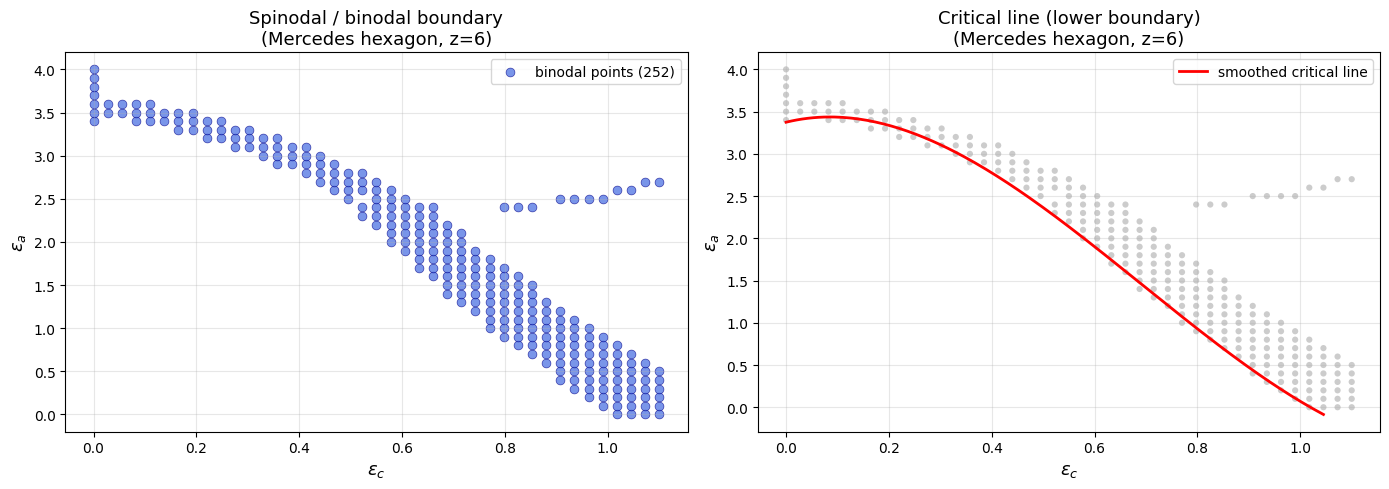

Loaded spinodal_hexagon7_results_mercedes_torch.npz (n_binodals=252)
Total points: 252
eps_a range: [0.000, 4.000]
eps_c range: [0.000, 1.100]


In [2]:
import os
import json
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import UnivariateSpline

# Must match base_filename in the save cell (without .npz)
SPINODAL_BASE = "../data/spinodal_hexagon7_results_mercedes_torch"
NPZ_PATH = f"{SPINODAL_BASE}.npz"

if not os.path.isfile(NPZ_PATH):
    raise FileNotFoundError(
        f"Could not find {NPZ_PATH!r}. Run the scan cell and save, or change SPINODAL_BASE."
    )

data = np.load(NPZ_PATH, allow_pickle=True)
points_arr = np.asarray(data["points"], dtype=float)

meta_path = f"{SPINODAL_BASE}_metadata.json"
meta_note = ""
if os.path.isfile(meta_path):
    with open(meta_path) as f:
        meta = json.load(f)
    meta_note = f" (n_binodals={meta.get('n_binodals', '?')})"

if points_arr.size == 0 or points_arr.shape[0] == 0:
    print(f"No points in {NPZ_PATH}{meta_note}")
else:
    if points_arr.ndim == 1:
        points_arr = points_arr.reshape(-1, 2)
    eps_a_pts = points_arr[:, 0]
    eps_c_pts = points_arr[:, 1]

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    ax = axes[0]
    ax.scatter(
        eps_c_pts, eps_a_pts,
        s=40, c="royalblue", marker="o", alpha=0.7,
        edgecolors="darkblue", linewidths=0.5,
        label=f"binodal points ({len(points_arr)})",
    )
    ax.set_xlabel(r"$\epsilon_c$", fontsize=13)
    ax.set_ylabel(r"$\epsilon_a$", fontsize=13)
    ax.set_title("Spinodal / binodal boundary\n(Mercedes hexagon, z=6)", fontsize=13)
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)

    ax2 = axes[1]
    ax2.scatter(
        eps_c_pts, eps_a_pts,
        s=20, c="grey", marker="o", alpha=0.4,
        edgecolors="none",
    )

    xq = np.round(eps_c_pts, 6)
    ux = np.unique(xq)
    xb, yb = [], []
    for xv in ux:
        mask = xq == xv
        yi = eps_a_pts[mask].min()
        if xv > 1.05:
            continue
        xb.append(float(xv))
        yb.append(float(yi))
    xb = np.array(xb)
    yb = np.array(yb)
    order = np.argsort(xb)
    xb, yb = xb[order], yb[order]

    if len(xb) >= 4:
        spl = UnivariateSpline(xb, yb, s=len(xb) * 0.5, k=min(3, len(xb) - 1))
        xs = np.linspace(xb.min(), xb.max(), 200)
        ax2.plot(xs, spl(xs), "r-", lw=2, label="smoothed critical line")

    ax2.set_xlabel(r"$\epsilon_c$", fontsize=13)
    ax2.set_ylabel(r"$\epsilon_a$", fontsize=13)
    ax2.set_title("Critical line (lower boundary)\n(Mercedes hexagon, z=6)", fontsize=13)
    ax2.legend(fontsize=10)
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    print(f"Loaded {NPZ_PATH}{meta_note}")
    print(f"Total points: {len(points_arr)}")
    print(f"eps_a range: [{eps_a_pts.min():.3f}, {eps_a_pts.max():.3f}]")
    print(f"eps_c range: [{eps_c_pts.min():.3f}, {eps_c_pts.max():.3f}]")

In [4]:
# -------------------- parsing --------------------
import re
pattern = re.compile(r'^\s*(?:θ\*|theta\*)\s*:\s*\(([^)]*)\)')
def first_two_from_line(s: str):
    m = pattern.match(s)
    if not m:
        return None
    inside = m.group(1)
    parts = [p.strip() for p in inside.split(',')]
    if len(parts) >= 2:
        try:
            return float(parts[0]), float(parts[1])
        except ValueError:
            return None

f = open('../data/mc_spinodal_hex_mercedes.txt','r')
lines = f.readlines()
f.close()

xs, ys = [], []
for line in lines:
    if line.startswith('theta'):
        out = first_two_from_line(line)
        if out is None:
            continue
        x, y = out
        xs.append(x); ys.append(y)


In [5]:
from scipy.ndimage import gaussian_filter1d
def _fit_slope(x, y, k=10, side="left"):
    k = min(int(k), len(x))
    if k < 2:
        return 0.0
    if side == "left":
        xx, yy = x[:k], y[:k]
    else:
        xx, yy = x[-k:], y[-k:]
    A = np.vstack([xx, np.ones_like(xx)]).T
    m, b = np.linalg.lstsq(A, yy, rcond=None)[0]
    return float(m)
def gaussian_smooth_xy_no_edge_curvature(x, y, *, sigma=4.0, n=800, xlim=None, pad_mult=4, kfit=10):
    x = np.asarray(x, float); y = np.asarray(y, float)
    m = np.isfinite(x) & np.isfinite(y)
    x, y = x[m], y[m]
    idx = np.argsort(x)
    x, y = x[idx], y[idx]

    if xlim is None:
        x0, x1 = float(x.min()), float(x.max())
    else:
        x0, x1 = map(float, xlim)
        keep = (x >= x0) & (x <= x1)
        x, y = x[keep], y[keep]

    xg = np.linspace(x0, x1, int(n))
    yg = np.interp(xg, x, y)

    pad = int(max(8, pad_mult * sigma))
    mL = _fit_slope(xg, yg, k=kfit, side="left")
    mR = _fit_slope(xg, yg, k=kfit, side="right")

    dx = xg[1] - xg[0]
    left_x  = xg[0]  - dx * np.arange(pad, 0, -1)
    right_x = xg[-1] + dx * np.arange(1, pad + 1)
    left_y  = yg[0]  + mL * (left_x  - xg[0])
    right_y = yg[-1] + mR * (right_x - xg[-1])

    yg_pad = np.concatenate([left_y, yg, right_y])
    ygs_pad = gaussian_filter1d(yg_pad, sigma=float(sigma), mode="nearest")
    ygs = ygs_pad[pad:-pad]
    return xg, ygs
def trim_at_floor(x, y, floor=0.0, eps=2e-2):
    x = np.asarray(x); y = np.asarray(y)
    m = np.isfinite(x) & np.isfinite(y)
    x, y = x[m], y[m]
    idx = np.where(y <= (floor + eps))[0]
    if idx.size == 0:
        return x, y
    k = int(idx[0])
    return x[:k+1], y[:k+1]
points={}
for j in range(len(eps_c_pts)):
    eps_c = eps_c_pts[j]; eps_a=eps_a_pts[j]
    if eps_c not in points.keys():
        points[eps_c]=eps_a
    else:
        if eps_a < points[eps_c]:
            points[eps_c]=eps_a
eps_c_m=list(points.keys())
eps_a_m=list(points.values())

x3 = np.array(eps_c_m, float)
y3 = np.array(eps_a_m, float)                            # SAFT
x3g, y3gs = gaussian_smooth_xy_no_edge_curvature(x3, y3, sigma=50, n=900)

# stop drawing when they hit ~0 -> removes vertical end segment
#x3g, y3gs = trim_at_floor(x3g, y3gs, floor=0.0, eps=0.02)
with open("../data/spinodal_tri_saft.json", "r") as f:
    data = json.load(f)
spinodal2_m=np.array(data)

eps_as=np.linspace(0,5,21)
eps_cs=np.linspace(0,1.5,31)
eps_c_spinodal2_m=[]
eps_a_spinodal2_m=[]
for j in range(len(eps_cs)):
    if len(np.where(spinodal2_m[:,j])[0])>0 and eps_cs[j]<=1.22:
        eps_a_spinodal2_m.append(eps_as[np.min(np.where(spinodal2_m[:,j]==1)[0])])
        eps_c_spinodal2_m.append(eps_cs[j])
x2 = np.array(eps_a_spinodal2_m, float)
y2 = np.array(eps_c_spinodal2_m, float)                            # SAFT
x2g, y2gs = gaussian_smooth_xy_no_edge_curvature(x2, y2, sigma=50, n=900)
#x3g, y3gs = trim_at_floor(x3g, y3gs, floor=0.0, eps=0.02)
x1g, y1gs = gaussian_smooth_xy_no_edge_curvature(xs, ys, sigma=50, n=900)

In [7]:
# -------------------- parsing --------------------
import re
pattern = re.compile(r'^\s*(?:θ\*|theta\*)\s*:\s*\(([^)]*)\)')
def first_two_from_line(s: str):
    m = pattern.match(s)
    if not m:
        return None
    inside = m.group(1)
    parts = [p.strip() for p in inside.split(',')]
    if len(parts) >= 2:
        try:
            return float(parts[0]), float(parts[1])
        except ValueError:
            return None

f = open('../results_logs/output_mc_mercedes.out','r')
lines = f.readlines()
f.close()

xms, yms = [], []
for line in lines:
    if line.startswith('theta'):
        out = first_two_from_line(line)
        if out is None:
            continue
        x, y = out
        xms.append(x); yms.append(y)


In [9]:
xg, ygs = gaussian_smooth_xy_no_edge_curvature(xms, yms, sigma=50, n=900)
x5g, y5gs = gaussian_smooth_xy_no_edge_curvature(xb, yb, sigma=50, n=900)


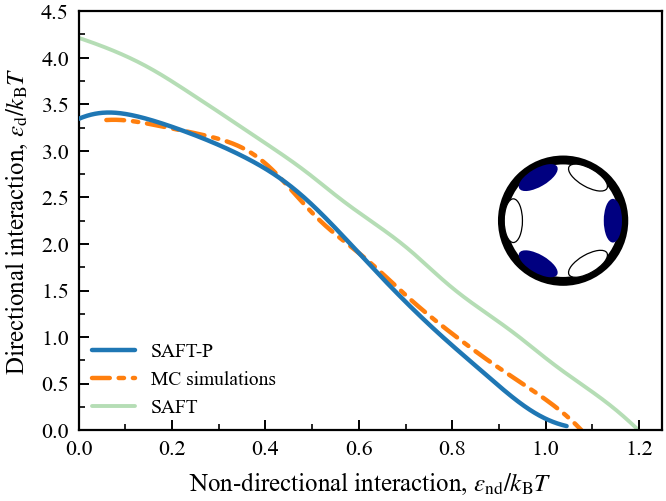

In [15]:

import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator
from matplotlib.patches import Circle, Ellipse

# ----------------------------- PRL/APS-like styling -----------------------------
mpl.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "Times", "STIXGeneral", "DejaVu Serif"],
    "mathtext.fontset": "stix",
    "font.size": 8,
    "axes.labelsize": 9,
    "axes.titlesize": 9,
    "legend.fontsize": 7,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "axes.linewidth": 0.8,
    "lines.linewidth": 1.6,
    "lines.solid_capstyle": "round",
    "lines.dash_capstyle": "round",
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.major.size": 3.5,
    "ytick.major.size": 3.5,
    "xtick.minor.size": 2.0,
    "ytick.minor.size": 2.0,
    "xtick.major.width": 0.7,
    "ytick.major.width": 0.7,
    "xtick.minor.width": 0.6,
    "ytick.minor.width": 0.6,
    "legend.frameon": False,
    "savefig.bbox": "tight",
    "savefig.pad_inches": 0.02,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

# Expected from the previous parsing/smoothing cells:
#   x1g, y1gs  -> MC boundary
#   x5g, y5gs  -> SAFT-P boundary
#   x2g, y2gs  -> SAFT baseline, but currently stored as (eps_a, eps_c)
needed = ["x1g", "y1gs", "x5g", "y5gs", "x2g", "y2gs"]
missing = [name for name in needed if name not in globals()]
if missing:
    raise RuntimeError(
        "Run the Mercedes parsing/smoothing cells first. Missing variables: "
        + ", ".join(missing)
    )

# ----------------------------- plotting -----------------------------
fig = plt.figure(figsize=(3.375, 2.55), dpi=200, constrained_layout=True)
ax = fig.add_subplot(111)

# Curves
ax.plot(x5g, y5gs, label=r"SAFT-P", zorder=3)
ax.plot(x1g, y1gs, linestyle=(0, (4, 2, 1.2, 2)), label=r"MC simulations", zorder=2)
ax.plot(y2gs, x2g, linewidth=1.4, alpha=0.35, label=r"SAFT", zorder=1)

ax.set_xlabel(r"Non-directional interaction, $\epsilon_{\mathrm{nd}}/k_{\mathrm{B}}T$")
ax.set_ylabel(r"Directional interaction, $\varepsilon_{\mathrm{d}}/k_{\mathrm{B}}T$")

ax.xaxis.set_minor_locator(AutoMinorLocator(2))
ax.yaxis.set_minor_locator(AutoMinorLocator(2))

ax.set_xlim(0.0, 1.25)
ax.set_ylim(0.0, 4.5)

ax.legend(loc="lower left", handlelength=2.2, borderaxespad=0.3)

# ----------------------------- inset schematic: Mercedes particle -----------------------------
ax_in = ax.inset_axes([0.70, 0.07, 0.26, 0.86])
ax_in.set_axis_off()
ax_in.set_facecolor("none")
for sp in ax_in.spines.values():
    sp.set_visible(False)

ax_in.set_aspect("equal", adjustable="box")
ax_in.set_xlim(-1.25, 1.25)
ax_in.set_ylim(-1.25, 1.25)

R = 1.0
ax_in.add_patch(Circle((0.0, 0.0), R, fill=False, linewidth=3.2, edgecolor="black"))

# Filled attractive patches
for theta in [0, 120, 240]:
    th = np.deg2rad(theta)
    cx = 0.82 * np.cos(th)
    cy = 0.82 * np.sin(th)
    ax_in.add_patch(Ellipse(
        (cx, cy),
        0.30, 0.72,
        angle=theta,
        linewidth=0.0,
        fill=True,
        color="navy",
    ))

# Complementary white patches
for theta in [60, 180, 300]:
    th = np.deg2rad(theta)
    cx = 0.82 * np.cos(th)
    cy = 0.82 * np.sin(th)
    ax_in.add_patch(Ellipse(
        (cx, cy),
        0.30, 0.72,
        angle=theta,
        linewidth=0.45,
        fill=True,
        facecolor="white",
        edgecolor="black",
    ))

fig.savefig("../figures/phase_diagram_mercedes.pdf")
fig.savefig("../figures/phase_diagram_mercedes.png", dpi=600)
plt.show()
